In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pytensor.tensor as pt
import pymc as pm
from __future__ import annotations
from pathlib import Path
import os

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
# ------------------------------------------------------------
# 0) Define Data Path
# ------------------------------------------------------------
try:
    # 1. Preferred method for scripts (.py files):
    # Get the directory of the current script file.
    BASE_DIR = Path(__file__).parent
except NameError:
    # 2. Fallback for notebooks (Colab/Jupyter):
    # Use the current working directory, which should be the Git root
    # after cloning and changing directory (see Colab setup below).
    BASE_DIR = Path(os.getcwd())

# Define the relative path to the raw data folder
RAW_DATA_PATH = BASE_DIR / "data"

# Sanity check (Optional, but useful for debugging)
if not RAW_DATA_PATH.is_dir():
    raise FileNotFoundError(
        f"The data/raw directory was not found at the expected path: {RAW_DATA_PATH}"
    )

print(f"Data will be loaded from: {RAW_DATA_PATH}")


# ------------------------------------------------------------
# 1) Load data
# ------------------------------------------------------------
# ------------------------------------------------------------
# Use the RAW_DATA_PATH variable and the / operator from pathlib
# to construct the full file path.

df_sorted = pd.read_excel(RAW_DATA_PATH / "df_sorted.xlsx")


Data will be loaded from: /content/Silk-Road-Tourism-Spillovers-Spatial-Bayesian-Durbin-Model/data


In [4]:
cities = {
    'Azerbaijan': (40.4093, 49.8671),     # Baku
    'China': (34.3416, 108.9398),         # Xi'an
    'Egypt': (31.2001, 29.9187),          # Alexandria
    'Georgia': (42.2679, 42.7180),        # Kutaisi
    'India': (27.0920, 77.6689),          # Fatehpur Sikri
    'Iran': (35.5760, 53.3950),           # Semnan
    'Italy': (45.4408, 12.3155),          # Venice
    'Kazakhstan': (43.2220, 76.8512),     # Almaty
    'Kyrgyzstan': (41.1000, 75.3500),     # Tash Rabat
    'Saudi Arabia': (21.4858, 39.1925),   # Jeddah
    'Türkiye': (40.1828, 29.0666),         # Bursa
}


In [5]:
from geopy.distance import geodesic

# --- Step 1: Define the list of countries in a consistent order ---
country_list = sorted(cities.keys())
N = len(country_list)

# --- Step 2: Extract geographic coordinates for each country ---
coords = [cities[c] for c in country_list]

# --- Step 3: Construct the distance matrix ---
# Compute pairwise great-circle distances (in kilometers) using geodesic distance
dist_matrix = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        if i != j:
            dist_matrix[i, j] = geodesic(coords[i], coords[j]).kilometers
        else:
            dist_matrix[i, j] = np.inf  # avoid division by zero on the diagonal

# --- Step 4: Construct the inverse-distance weight matrix ---
W_distance_inv = 1 / dist_matrix

# --- Step 5: Row-standardize the matrix (so that each row sums to 1) ---
W_distance_inv = W_distance_inv / W_distance_inv.sum(axis=1, keepdims=True)


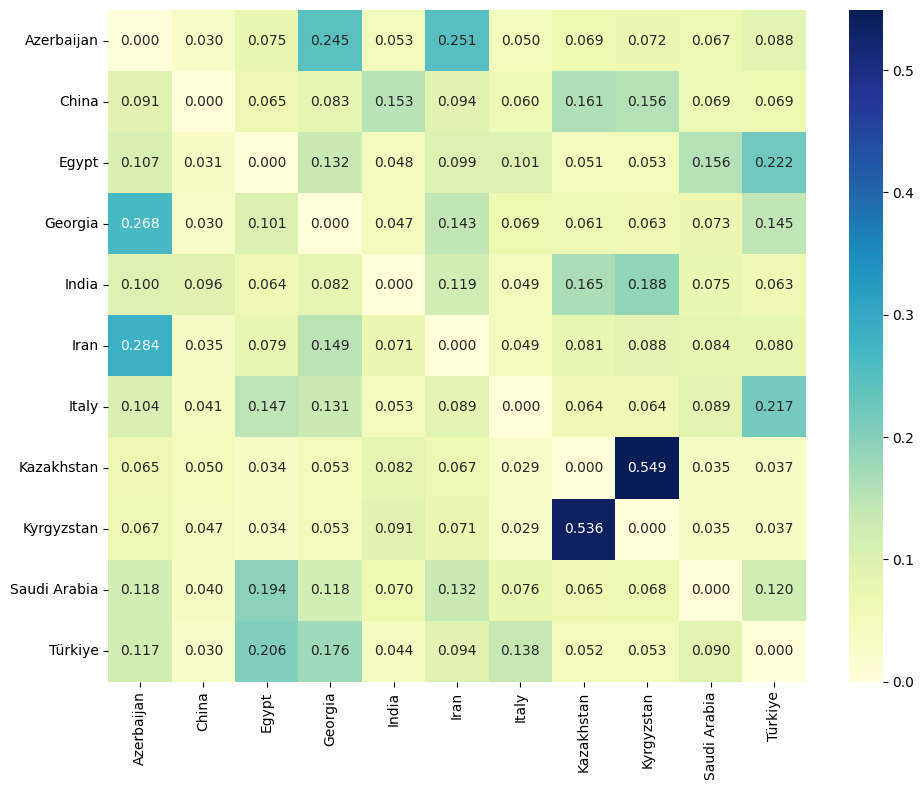

In [6]:
# Filter to the set of countries included in the analysis
selected_countries = [
    "Azerbaijan",
    "China",
    "Egypt",
    "Georgia",
    "India",
    "Iran",
    "Italy",
    "Kazakhstan",
    "Kyrgyzstan",
    "Saudi Arabia",
    "Türkiye"
]


plt.figure(figsize=(10, 8))
sns.heatmap(
    W_distance_inv,
    xticklabels=selected_countries,
    yticklabels=selected_countries,
    cmap="YlGnBu",
    annot=True,
    fmt=".3f" # Display 3 decimal places for precision
)
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd

W_geo = pd.DataFrame(W_distance_inv, columns=country_list, index=country_list)
W_geo.to_excel("W_geo.xlsx")
